In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# ============================================================
# LOAD DATA
# ============================================================

In [3]:
url = "https://raw.githubusercontent.com/erlanggapratamaP/mobileprices/master/train.csv"
df = pd.read_csv(url)

In [4]:
df.shape

(2000, 21)

In [5]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [6]:
# ============================================================
# EDA - STRUCTURE & MISSING VALUES
# ============================================================

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [8]:
df.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [9]:
# ============================================================
# EDA - TARGET DISTRIBUTION
# ============================================================

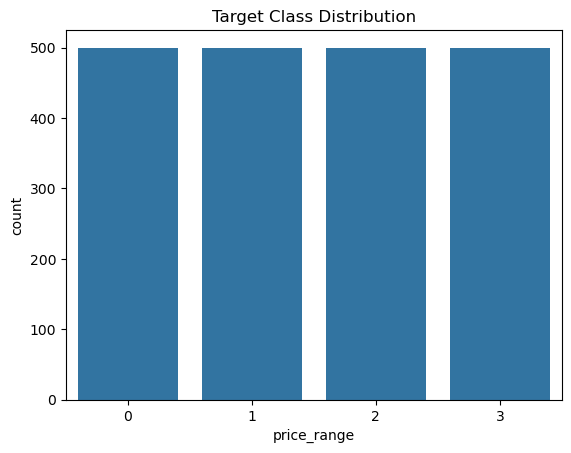

In [10]:
sns.countplot(x="price_range", data=df)
plt.title("Target Class Distribution")
plt.show()

In [11]:
df["price_range"].value_counts()

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64

In [12]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [13]:
# ============================================================
# EDA - SUSPICIOUS ZERO VALUES CHECK
# ============================================================

In [14]:
print("px_height = 0 count:", (df['px_height'] == 0).sum())
print("sc_w = 0 count:", (df['sc_w'] == 0).sum())

# What % of the data do these represent?
print("px_height=0 %:", (df['px_height'] == 0).mean() * 100)
print("sc_w=0 %:", (df['sc_w'] == 0).mean() * 100)

px_height = 0 count: 2
sc_w = 0 count: 180
px_height=0 %: 0.1
sc_w=0 %: 9.0


In [15]:
# ============================================================
# DATA CLEANING - SUSPICIOUS ZERO VALUES
# ============================================================

In [16]:
# px_height=0: negligible (0.1%), safe to drop
df = df[df['px_height'] != 0].copy()

# sc_w=0: too significant to drop (9%), treat as missing value
# Replace 0 with NaN, then apply class-wise median imputation (same logic as Pima Diabetes in 02)
df['sc_w'] = df['sc_w'].replace(0, np.nan)

print("sc_w missing before imputation:", df['sc_w'].isnull().sum())

df['sc_w'] = df.groupby('price_range')['sc_w'].transform(lambda x: x.fillna(x.median()))

print("sc_w missing after imputation:", df['sc_w'].isnull().sum())
df.shape

sc_w missing before imputation: 179
sc_w missing after imputation: 0


(1998, 21)

In [17]:
# ============================================================
# OUTLIER DETECTION - IQR METHOD
# ============================================================


In [20]:
continuous_cols = ["battery_power", "clock_speed","fc","int_memory","m_dep","mobile_wt","n_cores","pc","px_height","px_width","ram","sc_h","sc_w","talk_time"]

In [22]:
outlier_summary = {}

for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR= Q3 -Q1 
    lower = Q1 -1.5 *IQR
    upper = Q3 +1.5*IQR
    outlier_count = ((df[col] < lower ) | (df[col] > upper)).sum()
    outlier_summary[col] = outlier_count

for col, count in outlier_summary.items():
    print(f"{col}: {count} outliers")

battery_power: 0 outliers
clock_speed: 0 outliers
fc: 18 outliers
int_memory: 0 outliers
m_dep: 0 outliers
mobile_wt: 0 outliers
n_cores: 0 outliers
pc: 0 outliers
px_height: 2 outliers
px_width: 0 outliers
ram: 0 outliers
sc_h: 0 outliers
sc_w: 0 outliers
talk_time: 0 outliers


In [23]:
# ============================================================
# OUTLIER INSPECTION - ARE THESE REAL OR ERRORS?
# ============================================================

In [24]:

# fc: front camera megapixels — check actual outlier values
Q1_fc = df['fc'].quantile(0.25)
Q3_fc = df['fc'].quantile(0.75)
IQR_fc = Q3_fc - Q1_fc
upper_fc = Q3_fc + 1.5 * IQR_fc

print("fc upper bound:", upper_fc)
print("fc outlier values:\n", df.loc[df['fc'] > upper_fc, 'fc'].sort_values().unique())
print("fc max possible value in dataset:", df['fc'].max())

print("\n---\n")

# px_height: screen resolution height — check actual outlier values
Q1_px = df['px_height'].quantile(0.25)
Q3_px = df['px_height'].quantile(0.75)
IQR_px = Q3_px - Q1_px
upper_px = Q3_px + 1.5 * IQR_px

print("px_height upper bound:", upper_px)
print("px_height outlier values:\n", df.loc[df['px_height'] > upper_px, 'px_height'].sort_values())

fc upper bound: 16.0
fc outlier values:
 [17 18 19]
fc max possible value in dataset: 19

---

px_height upper bound: 1943.375
px_height outlier values:
 988     1949
1771    1960
Name: px_height, dtype: int64


In [25]:
# ============================================================
# MULTICOLLINEARITY CHECK - CORRELATION MATRIX
# ============================================================

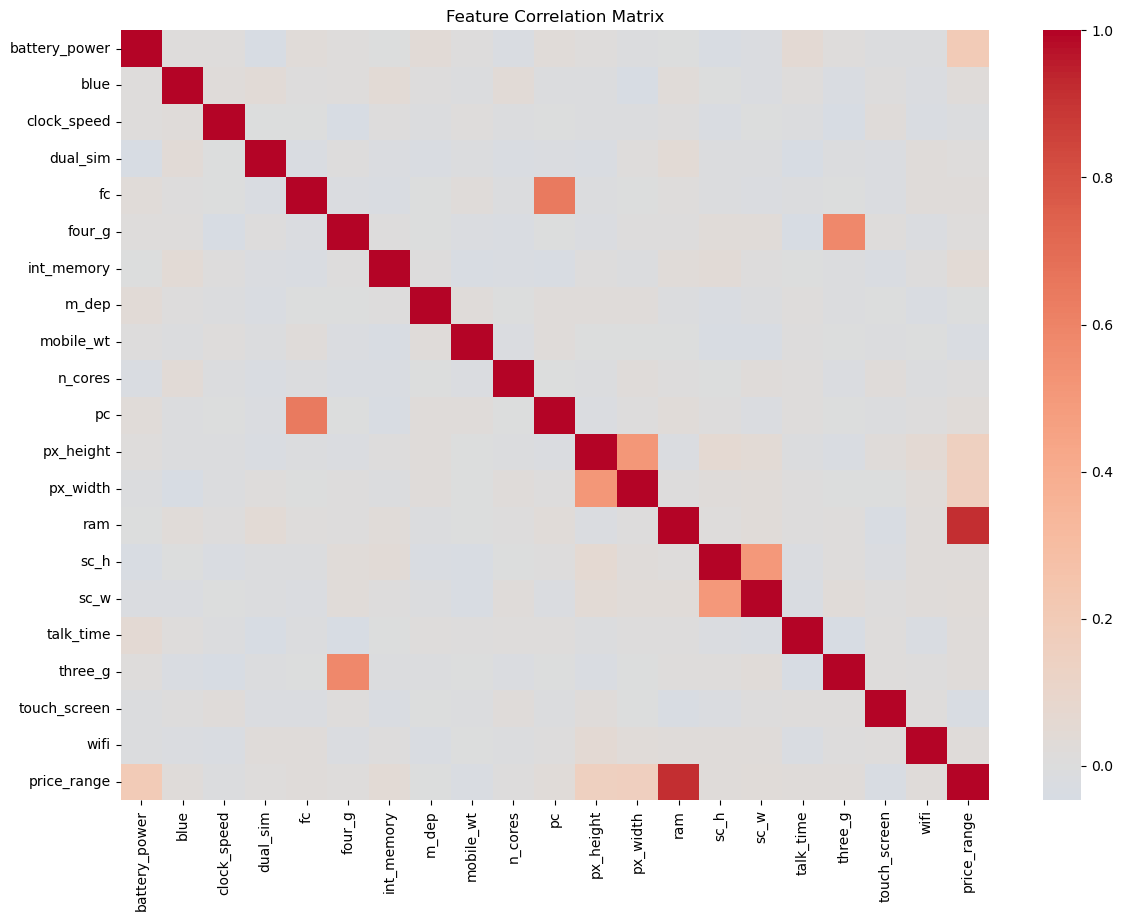

In [35]:
plt.figure(figsize=(14,10))
corr_matrix= df.corr()
sns.heatmap(corr_matrix, annot=False, cmap = "coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

In [32]:
# Print only strong correlations (|corr| > 0.5), excluding self-correlation
strong_corr = corr_matrix[(corr_matrix.abs() > 0.5) & (corr_matrix.abs() < 1.0)]
print(strong_corr.stack().drop_duplicates())

fc         pc             0.644624
four_g     three_g        0.584069
px_height  px_width       0.512428
ram        price_range    0.916985
sc_h       sc_w           0.502940
dtype: float64


In [36]:
# ============================================================
# MULTICOLLINEARITY CHECK - VIF
# ============================================================

In [37]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [38]:
# Exclude target variable from VIF calculation
X_vif = df.drop("price_range", axis=1)

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values,i) for i in range(X_vif.shape[1])]

print(vif_data.sort_values("VIF", ascending=False))

          feature        VIF
8       mobile_wt  12.981768
12       px_width  11.800644
14           sc_h  11.648499
0   battery_power   8.071030
10             pc   6.218371
17        three_g   6.187590
16      talk_time   4.854467
15           sc_w   4.692073
13            ram   4.685837
9         n_cores   4.647135
11      px_height   4.281041
2     clock_speed   4.257364
6      int_memory   3.962488
7           m_dep   3.913997
4              fc   3.411340
5          four_g   3.189619
19           wifi   2.022295
3        dual_sim   2.016596
18   touch_screen   1.986754
1            blue   1.983346


In [39]:
# ============================================================
# TRAIN/TEST SPLIT
# ============================================================

In [40]:
from sklearn.model_selection import train_test_split

In [42]:
X = df.drop("price_range",axis=1)
y= df["price_range"]

X_train, X_test, y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state=42, stratify=y)

In [43]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\n Train class distribution\n", y_train.value_counts(normalize=True))
print("\n Test class distribution\n", y_test.value_counts(normalize=True))

Train shape: (1598, 20)
Test shape: (400, 20)

 Train class distribution
 price_range
0    0.250313
2    0.250313
1    0.249687
3    0.249687
Name: proportion, dtype: float64

 Test class distribution
 price_range
3    0.25
1    0.25
0    0.25
2    0.25
Name: proportion, dtype: float64


In [44]:
# ============================================================
# SCALING - STANDARDSCALER
# ============================================================

In [45]:
from sklearn.preprocessing import StandardScaler

In [46]:
scaler= StandardScaler()

In [47]:
# Fit only on train transform both train and test(leekage preventeion)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# convert back to  DataFrame for readability (optional but heplful)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns,index = X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index =X_test.index)

In [49]:
print(X_train_scaled.describe().loc[["mean","std"]])

      battery_power          blue   clock_speed      dual_sim            fc  \
mean  -4.779934e-17 -8.448255e-17 -3.657205e-16 -1.228332e-16  4.446450e-17   
std    1.000313e+00  1.000313e+00  1.000313e+00  1.000313e+00  1.000313e+00   

            four_g    int_memory         m_dep     mobile_wt       n_cores  \
mean  1.022684e-16 -1.967554e-16 -9.782190e-17 -2.000903e-17  1.022684e-16   
std   1.000313e+00  1.000313e+00  1.000313e+00  1.000313e+00  1.000313e+00   

                pc     px_height      px_width           ram          sc_h  \
mean  1.078264e-16  1.222774e-16  5.224579e-17 -1.067148e-16 -1.567374e-16   
std   1.000313e+00  1.000313e+00  1.000313e+00  1.000313e+00  1.000313e+00   

              sc_w     talk_time       three_g  touch_screen          wifi  
mean  1.556258e-17 -8.337094e-17  9.281965e-17  1.878625e-16 -9.337545e-17  
std   1.000313e+00  1.000313e+00  1.000313e+00  1.000313e+00  1.000313e+00  


In [50]:
# ============================================================
# BASELINE MODEL - KNN (DEFAULT PARAMETERS)
# ============================================================

In [52]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [54]:
# Default k=5, no tuning yet - establishes a reference point
knn_baseline = KNeighborsClassifier(n_neighbors=5)
knn_baseline.fit(X_train_scaled,y_train)

y_pred_baseline = knn_baseline.predict(X_test_scaled)

print("Baseline Accuracy:", accuracy_score(y_test,y_pred_baseline))
print("Baseline F1 (macro):", f1_score(y_test, y_pred_baseline, average = "macro"))
print("\n ", classification_report(y_test,y_pred_baseline))

Baseline Accuracy: 0.5325
Baseline F1 (macro): 0.534675183204595

                precision    recall  f1-score   support

           0       0.63      0.73      0.68       100
           1       0.39      0.45      0.42       100
           2       0.44      0.43      0.43       100
           3       0.74      0.52      0.61       100

    accuracy                           0.53       400
   macro avg       0.55      0.53      0.53       400
weighted avg       0.55      0.53      0.53       400



In [55]:
# ============================================================
# HYPERPARAMETER TUNING - GRIDSEARCHCV
# ============================================================

In [56]:
from sklearn.model_selection import GridSearchCV

In [61]:
param_grid = {
    "n_neighbors": [3,5,7,9,11,15,20,30,40,50,75,100],
    "weights": ["uniform","distance"],
    "metric" : ["euclidean", "manhattan","minkowski"]
}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)
grid_search.fit(X_train_scaled,y_train)

print("Best params:", grid_search.best_params_)
print("Best CV f1_score:", grid_search.best_score_)

Best params: {'metric': 'manhattan', 'n_neighbors': 100, 'weights': 'distance'}
Best CV f1_score: 0.7177667097781919


In [62]:
# ============================================================
# TUNED MODEL - TEST SET EVALUATION
# ============================================================

In [63]:
best_knn = grid_search.best_estimator_

y_pred_tuned = best_knn.predict(X_test_scaled)

print("Tuned Test Accuracy: ", accuracy_score(y_test,y_pred_tuned))
print("Tuned Test F1 (macro):", f1_score(y_test,y_pred_tuned, average="macro"))
print("\n", classification_report(y_test,y_pred_tuned))

# overfit check: compare train vs test performance
y_pred_train = best_knn.predict(X_train_scaled)
print("Train F1 macro:", f1_score(y_train,y_pred_train, average="macro"))
print("Overfit gap:", f1_score(y_train,y_pred_train, average="macro") - f1_score(y_test,y_pred_tuned, average="macro"))

Tuned Test Accuracy:  0.7325
Tuned Test F1 (macro): 0.7324520783280375

               precision    recall  f1-score   support

           0       0.83      0.89      0.86       100
           1       0.68      0.59      0.63       100
           2       0.59      0.69      0.64       100
           3       0.84      0.76      0.80       100

    accuracy                           0.73       400
   macro avg       0.74      0.73      0.73       400
weighted avg       0.74      0.73      0.73       400

Train F1 macro: 1.0
Overfit gap: 0.2675479216719625


In [65]:
# ============================================================
# K vs CV SCORE - EXTENDED RANGE
# ==========================================================

In [67]:
from sklearn.model_selection import cross_val_score

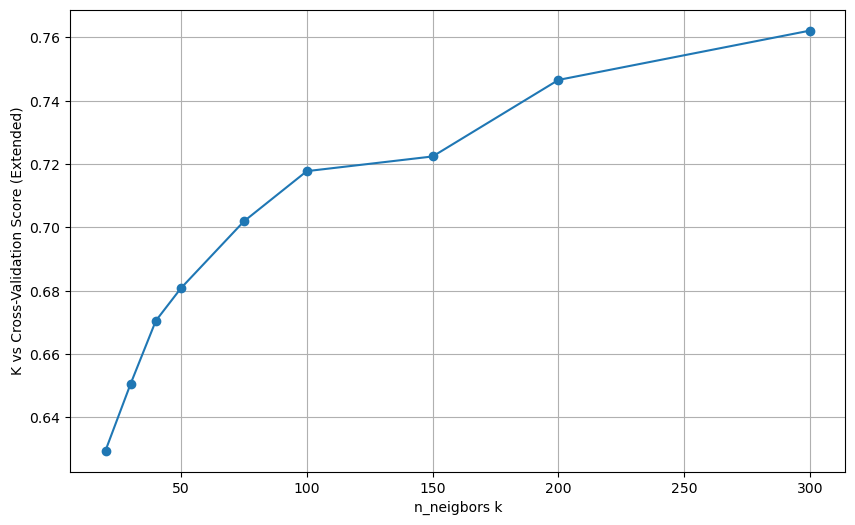

     k  cv_f1_macro
0   20     0.629547
1   30     0.650662
2   40     0.670527
3   50     0.680834
4   75     0.701915
5  100     0.717767
6  150     0.722406
7  200     0.746564
8  300     0.762144


In [69]:
k_range= [20,30,40,50,75,100,150,200,300]
cv_scores= []

for k in k_range:
    knn_temp= KNeighborsClassifier(n_neighbors = k, weights="distance", metric="manhattan")
    scores = cross_val_score(knn_temp,X_train_scaled,y_train,cv=5,scoring="f1_macro")
    cv_scores.append(scores.mean())

plt.figure(figsize=(10,6))
plt.plot(k_range,cv_scores,marker="o")
plt.xlabel("n_neigbors k")
plt.ylabel("K vs Cross-Validation Score (Extended)")
plt.grid(True)
plt.show()

print(pd.DataFrame({"k": k_range, "cv_f1_macro": cv_scores}))

In [70]:
# ============================================================
# K vs CV SCORE AND TEST SCORE - CHECKING FOR TRUE PLATEAU
# ============================================================

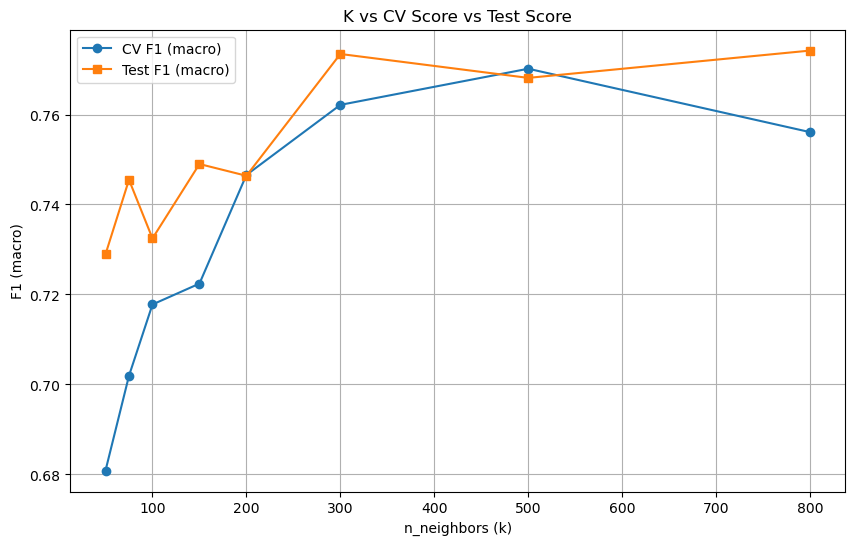

     k  cv_f1_macro  test_f1_macro
0   50     0.680834       0.728924
1   75     0.701915       0.745491
2  100     0.717767       0.732452
3  150     0.722406       0.748992
4  200     0.746564       0.746378
5  300     0.762144       0.773457
6  500     0.770179       0.768143
7  800     0.756082       0.774214


In [71]:
k_range = [50, 75, 100, 150, 200, 300, 500, 800]
cv_scores = []
test_scores = []

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='manhattan')
    scores = cross_val_score(knn_temp, X_train_scaled, y_train, cv=5, scoring='f1_macro')
    cv_scores.append(scores.mean())
    
    knn_temp.fit(X_train_scaled, y_train)
    test_pred = knn_temp.predict(X_test_scaled)
    test_scores.append(f1_score(y_test, test_pred, average='macro'))

plt.figure(figsize=(10, 6))
plt.plot(k_range, cv_scores, marker='o', label='CV F1 (macro)')
plt.plot(k_range, test_scores, marker='s', label='Test F1 (macro)')
plt.xlabel('n_neighbors (k)')
plt.ylabel('F1 (macro)')
plt.title('K vs CV Score vs Test Score')
plt.legend()
plt.grid(True)
plt.show()

print(pd.DataFrame({'k': k_range, 'cv_f1_macro': cv_scores, 'test_f1_macro': test_scores}))

In [77]:
# ============================================================
# FINAL MODEL - K=300
# ============================================================

final_knn = KNeighborsClassifier(n_neighbors=300, weights='distance', metric='manhattan')
final_knn.fit(X_train_scaled, y_train)

y_pred_final = final_knn.predict(X_test_scaled)

print("Final Test Accuracy:", accuracy_score(y_test, y_pred_final))
print("Final Test F1 (macro):", f1_score(y_test, y_pred_final, average='macro'))
print("\n", classification_report(y_test, y_pred_final))

Final Test Accuracy: 0.7725
Final Test F1 (macro): 0.7734567981627306

               precision    recall  f1-score   support

           0       0.88      0.91      0.90       100
           1       0.71      0.65      0.68       100
           2       0.63      0.72      0.67       100
           3       0.88      0.81      0.84       100

    accuracy                           0.77       400
   macro avg       0.78      0.77      0.77       400
weighted avg       0.78      0.77      0.77       400



In [78]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

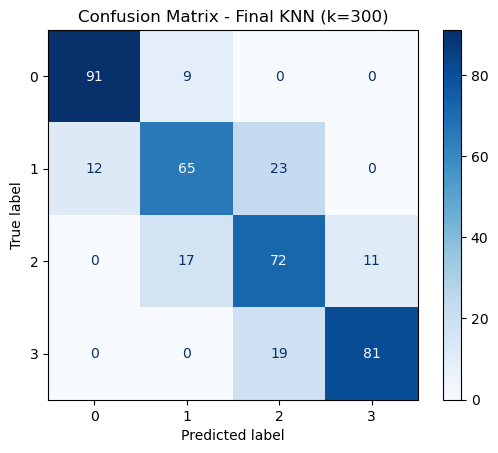

In [79]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred_final)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2, 3])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Final KNN (k=300)')
plt.show()

In [80]:
# ============================================================
# ROC-AUC (MULTICLASS, ONE-VS-REST) + LOG LOSS
# ============================================================

from sklearn.metrics import roc_auc_score, log_loss
from sklearn.preprocessing import label_binarize

# Get predicted probabilities
y_proba = final_knn.predict_proba(X_test_scaled)

# Align label_binarize classes with model.classes_ (lesson learned from 08_adaboost)
classes = final_knn.classes_
y_test_binarized = label_binarize(y_test, classes=classes)

roc_auc_macro = roc_auc_score(y_test_binarized, y_proba, average='macro', multi_class='ovr')
print("ROC-AUC (macro, OvR):", roc_auc_macro)

logloss = log_loss(y_test, y_proba)
print("Log Loss:", logloss)

ROC-AUC (macro, OvR): 0.9016166666666667
Log Loss: 1.1164408775878925


In [81]:
# ============================================================
# FEATURE IMPORTANCE - PERMUTATION IMPORTANCE
# ============================================================

In [82]:
from sklearn.inspection import permutation_importance

          feature  importance
13            ram    0.492888
0   battery_power    0.040505
11      px_height    0.024376
12       px_width    0.020993
18   touch_screen    0.020150
1            blue    0.017287
8       mobile_wt    0.016322
19           wifi    0.006683
15           sc_w    0.006579
3        dual_sim    0.004934
9         n_cores    0.003249
16      talk_time    0.001524
17        three_g    0.000647
2     clock_speed   -0.000326
10             pc   -0.001293
4              fc   -0.001304
5          four_g   -0.005060
6      int_memory   -0.005388
14           sc_h   -0.012592
7           m_dep   -0.025917


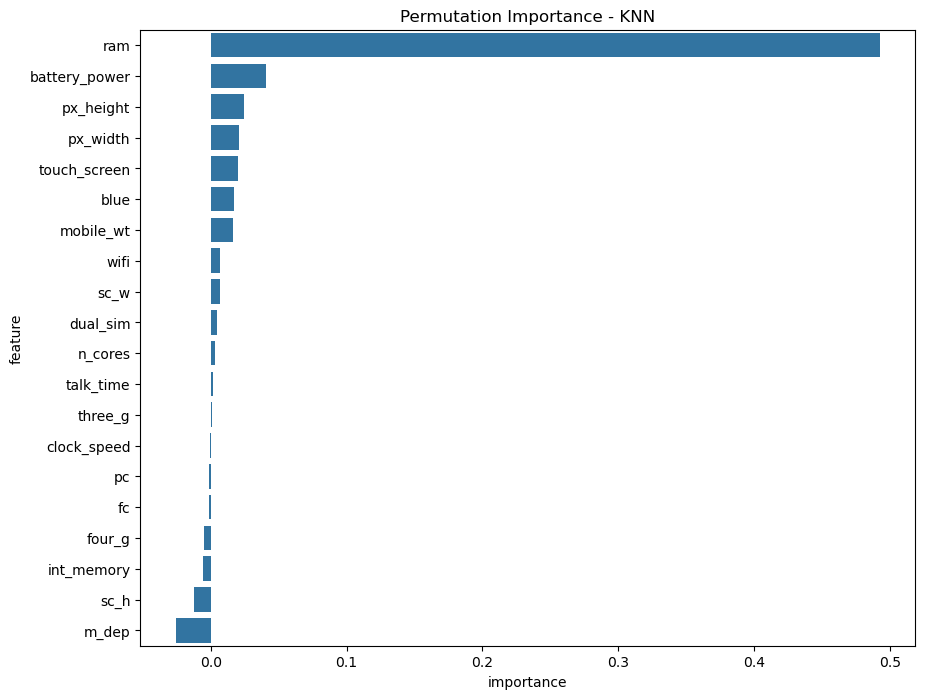

In [85]:
perm_importance = permutation_importance(
    final_knn, X_test_scaled, y_test, n_repeats=10, random_state=42, scoring="f1_macro"
)

importance_df = pd.DataFrame({

    "feature":X_test_scaled.columns,
    "importance": perm_importance.importances_mean
}).sort_values("importance", ascending=False)

print(importance_df)

plt.figure(figsize=(10,8))
sns.barplot(x="importance", y="feature", data=importance_df)
plt.title("Permutation Importance - KNN")
plt.show()

In [86]:
# ============================================================
# CROSS-VALIDATION - FINAL MODEL SUMMARY
# ============================================================


In [87]:
cv_scores_final = cross_val_score(
    final_knn, X_train_scaled, y_train,
    cv=5, scoring='f1_macro'
)

print("CV F1 (macro) scores per fold:", cv_scores_final)
print("CV F1 (macro) mean:", cv_scores_final.mean())
print("CV F1 (macro) std:", cv_scores_final.std())

CV F1 (macro) scores per fold: [0.76551982 0.73124383 0.82755542 0.75784654 0.72855325]
CV F1 (macro) mean: 0.7621437712303507
CV F1 (macro) std: 0.035753817614675165
